<img style="float: left;padding: 1.3em" src="https://indico.in2p3.fr/event/18313/logo-786578160.png">  

#  Gravitational Waves


#### Tutorial : processing a gravitational wave event

This notebook accompanies the lab script for the stage 3 lab, and makes use of data and resources provided by the [Gravitational-Wave Open Science Center (GWOSC)](https://www.gw-openscience.org).

In this notebook you will see examples of how to :
- search for an event
- read an event
- plot a timeseries
- fourier transform the time series to a frequency series
- plot a spectrogram
- make a Q transform
- generate a model waveform
- locate a signal within noise

All of these processes give you an insight into the mechanisms via which gravitational waves are detected by an interferometer. There are questions and investigations within the notebook (presented in blue) to complete as part of the lab, and then a more open-ended investigation at the end. 
    

In [2]:
import gwosc
import gwpy
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import pycbc

The gwosc package provides an interface to querying the open data releases hosted on https://gw-openscience.org from the GEO, LIGO, and Virgo gravitational-wave observatories.

If the package did not successfully install, check the steps in [Software Setup Instructions](https://github.com/gw-odw/odw-2021/blob/master/setup.md).

In [3]:
from gwosc.datasets import find_datasets
from gwosc import datasets
from gwosc.locate import get_event_urls
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries
from scipy.signal import get_window
import gwpy
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
import pylab

## Extension

In [4]:
# ============== create the simulation of waveform ===============
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=30.6,
                         mass2=35.6,
                         delta_t=1.0/16384,
                         f_lower=30)

In [5]:
# ========= import module ============
import urllib.request
import requests
import urllib
import numpy as np
from urllib.request import urlopen
import urllib3

# ================= open and download event ==================
file_name = 'https://gwosc.org/s/events/GW150914/P150914/fig1-observed-L.txt'
data = np.loadtxt(file_name, skiprows=1)

# =============== separate time and strain ==============
time_values = data[:, 0]
strain = data[:, 1]

for i in range(0,len(strain)):
    strain[i] = strain[i]*10**-18

In [6]:
# ================ find biggest strain for event ==============
highest_strain_event = 0
for i in range(0, len(strain)):
    if (strain[i] > highest_strain_event):
        highest_strain_event = strain[i]
        time_event = time_values[i]
print('The highest strain is:', f"{highest_strain_event}",'and the time is:', f"{time_event}")

The highest strain is: 1.0339254466649913e-18 and the time is: 0.41876220703125


In [7]:
# ================= find biggest strain for simulation =============
highest_strain_sim = 0
for i in range(0, len(hp)):
    if (hp[i] > highest_strain_sim):
        highest_strain_sim = hp[i]
        time_sim = hp.sample_times[i]
print('The highest strain is:', f"{highest_strain_sim}",'and the time is:', f"{time_sim}")

The highest strain is: 7.502561666555262e-19 and the time is: -0.003479698593749997


time event is: 0.41876220703125 s and time sim is: -0.003479698593749997 s

the shift is: 0.42224190562499997 s


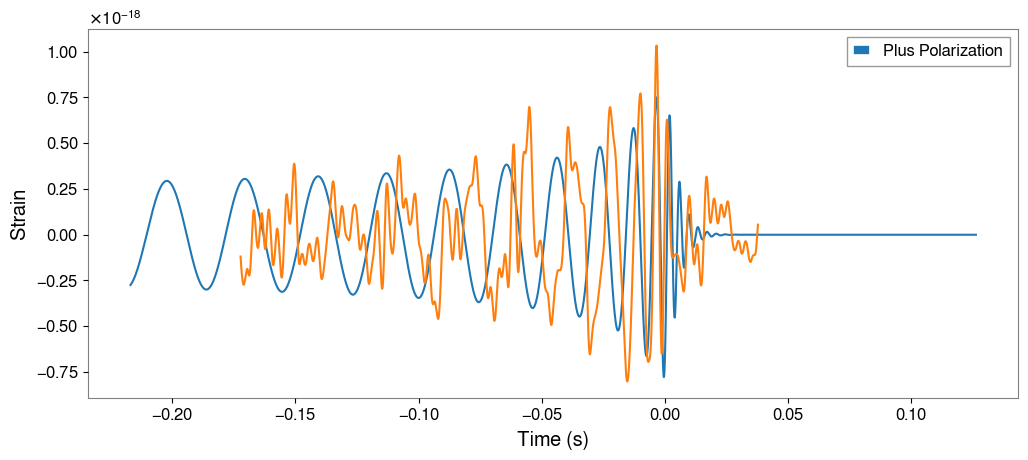

In [8]:
# =============== shift the maximum strain to have both sim and event comparable ==============
shift = time_event - time_sim
print('time event is:', time_event,'s','and time sim is:', time_sim, 's')

time_shifted = []
for i in range(0,len(time_values)):
    time_shifted.append(time_values[i] - shift)
print('')
print('the shift is:',shift,'s')

# ============= plot the waveforms ==========================
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
plt.plot(time_shifted, strain)
pylab.legend()
pylab.grid()
pylab.show()

# code from LIGO

In [ ]:
# ============ name event ===============
name_event = 'GW200202_154313'

# -- Helper python module to open LIGO data files
! wget -q -N https://www.gw-openscience.org/static/sample_code/readligo.py 
    
# -- Download 4096 second data files around GW150914
! wget -q -N https://www.gw-openscience.org/GW150914data/L-L1_LOSC_4_V2-1126257414-4096.hdf5
! wget -q -N https://www.gw-openscience.org/GW150914data/H-H1_LOSC_4_V2-1126257414-4096.hdf5
    
    
# -- Download 32 second data files around GW150914
! wget -q -N https://gwosc.org/eventapi/html/GWTC-3-confident/GW200202_154313/v1/H-H1_GWOSC_16KHZ_R1-1264691364-4096.hdf5
! wget -q -N https://gwosc.org/eventapi/html/GWTC-3-confident/GW200202_154313/v1/L-L1_GWOSC_16KHZ_R1-1264691364-4096.hdf5   
    
# -- Download waveform template
! wget -q -N https://www.gw-openscience.org/GW200202_154313/P150914/fig2-unfiltered-waveform-H.txt
    
# -- Download data from Figure 1 of GW150914 detection paper
! wget -q -N https://www.gw-openscience.org/GW200202_154313/P150914/fig1-observed-H.txt
! wget -q -N https://www.gw-openscience.org/GW200202_154313/P150914/fig1-residual-H.txt
! wget -q -N https://www.gw-openscience.org/GW200202_154313/P150914/fig1-observed-L.txt
! wget -q -N https://www.gw-openscience.org/GW200202_154313/P150914/fig1-residual-L.txt

^C
^C
^C
^C


In [44]:
# Standard python numerical analysis imports:
import numpy as np
import scipy
from scipy import signal
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt
import h5py
import json

# plotting items
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

# -- Set some parameters that control how plots are displayed
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams['lines.linewidth'] = .75

# LIGO-specific readligo.py 
# Download from https://www.gw-openscience.org/static/sample_code/readligo.py
import readligo as rl

In [48]:
# these 4096 second files are useful for computing more accurate psds
large_data_filenames = {'GW200202_154313': 'H-H1_GWOSC_16KHZ_R1-1264691364-4096.hdf5'}
fn_H1 = 'H-H1_' + large_data_filenames['GW200202_154313']
fn_L1 = 'L-L1_' + large_data_filenames['GW200202_154313']

# this is the approximate event time which is used in the papers
time_center = 1126259462

# get sample rate from the H1 data file
with h5py.File(fn_H1, 'r') as hdf_file:
    dt = hdf_file['strain/Strain'].attrs['Xspacing']
fs = int(1.0/dt)
print("Using sample rate of {0} Hz found in file: {1}".format(fs, fn_H1))

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'H-H1_H-H1_GWOSC_16KHZ_R1-1264691364-4096.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
def get_full_psds(eventnames, large_data_filenames,
                  make_plots=False, plot_others=False):
    """Obtains full 1024 second psds for all the events specified. Uses the Welch
    average technique, along with other less accurate techniques if
    specified. Can also plot the psd obtained.
    
    Args: 
        eventnames (list): list of events to get psds for
        large_datafilenames (dict): dictionary whose keys are the eventnames 
            and whose values are the filenames of the large amounts of strain
            data used, without the added 'H-<det>_'
        make_plots (bool, optional): if set to True, plot psd data
        plot_others (bool, optional): if set to True, also obtain psd data 
            without averaging as well as with no window
    
    Returns:
        dict: A dictionary containing psds for each detector for each event 
            specified in eventnames.
    """

    large_data_psds = {}
    for eventname in eventnames:
        large_data_psds[eventname] = {'H1': [], 'L1': []}

        # get filename
        fn_H1 = 'H-H1_' + large_data_filenames[eventname]
        fn_L1 = 'L-L1_' + large_data_filenames[eventname]

        # get strain data
        strain_H1, time_H1, chan_dict_H1 = rl.loaddata(fn_H1, 'H1')
        strain_L1, time_L1, chan_dict_L1 = rl.loaddata(fn_L1, 'L1')

        # both H1 and L1 will have the same time vector, so:
        time = time_H1

        indxt_around = np.where((time >= time_center - 512) & (
            time < time_center + 512))

        # number of sample for the fast fourier transform:
        NFFT = int( 4 * fs )           # Use 4 seconds of data for each fourier transform
        NOVL = int( 1 * NFFT / 2 )     # The number of points of overlap between segments used in Welch averaging
        psd_window = scipy.signal.tukey(NFFT, alpha=1./4)

        Pxx_H1, freqs = mlab.psd(strain_H1[indxt_around], Fs=fs, NFFT=NFFT,
                                 window=psd_window, noverlap=NOVL)
        Pxx_L1, freqs= mlab.psd(strain_L1[indxt_around], Fs=fs, NFFT=NFFT, 
                                window=psd_window, noverlap=NOVL)
        

        if (plot_others):
            # smaller window if we're not doing Welch's method
            short_indxt_away = np.where((time >= time_center - 2) & (
                time < time_center + 2))
            # psd using a tukey window but no welch averaging
            tukey_Pxx_H1, tukey_freqs = mlab.psd(
                strain_H1[short_indxt_away], Fs=fs, NFFT=NFFT, window=psd_window)
            # psd with no window, no averaging
            nowin_Pxx_H1, nowin_freqs = mlab.psd(
                strain_H1[short_indxt_away], Fs=fs, NFFT=NFFT, 
                window=mlab.window_none)

        # We will use interpolations of the PSDs computed above for whitening:
        psd_H1 = interp1d(freqs, Pxx_H1)
        psd_L1 = interp1d(freqs, Pxx_L1)

        large_data_psds[eventname]['H1'] = psd_H1
        large_data_psds[eventname]['L1'] = psd_L1

        if make_plots:
            plt.figure(figsize=(8, 5))
            # scale x and y axes
            plt.xscale('log', base=2)
            plt.yscale('log', base=10)

            # plot nowindow, tukey, welch together 
            plt.plot(nowin_freqs, nowin_Pxx_H1,'purple',label= 'No Window',
                     alpha=.8, linewidth=.5)
            plt.plot(tukey_freqs, tukey_Pxx_H1 ,'green',label='Tukey Window',
                     alpha=.8, linewidth=.5)
            plt.plot(freqs, Pxx_H1,'black',label='Welch Average', alpha=.8,
                     linewidth=.5)

            # plot 1/f^2
            # give it the right starting scale to fit with the rest of the plots
            # don't include zero frequency
            inverse_square = np.array(list(map(lambda f: 1 / (f**2), 
                                    nowin_freqs[1:])))
            # inverse starts at 1 to take out 1/0
            scale_index = 500 # chosen by eye to fit the plot
            scale = nowin_Pxx_H1[scale_index]  / inverse_square[scale_index]
            plt.plot(nowin_freqs[1:], inverse_square * scale,'red',
                     label= r'$1 / f^2$', alpha=.8, linewidth=1)

            plt.axis([20, 512, 1e-48, 1e-41])
            plt.ylabel('Sn(t)')
            plt.xlabel('Freq (Hz)')
            plt.legend(loc='upper center')
            plt.title('LIGO PSD data near ' + eventname + ' at H1')
            plt.show()

    return large_data_psds

In [ ]:
eventnames = ['GW200202_154313']
large_data_psds = get_full_psds(eventnames, large_data_filenames,
                                make_plots=True, plot_others=True)

In [ ]:
def whiten(strain, interp_psd, dt, phase_shift=0, time_shift=0):
    """Whitens strain data given the psd and sample rate, also applying a phase
    shift and time shift.

    Args:
        strain (ndarray): strain data
        interp_psd (interpolating function): function to take in freqs and output 
            the average power at that freq 
        dt (float): sample time interval of data
        phase_shift (float, optional): phase shift to apply to whitened data
        time_shift (float, optional): time shift to apply to whitened data (s)
    
    Returns:
        ndarray: array of whitened strain data
    """
    Nt = len(strain)
    # take the fourier transform of the data
    freqs = np.fft.rfftfreq(Nt, dt)

    # whitening: transform to freq domain, divide by square root of psd, then
    # transform back, taking care to get normalization right.
    hf = np.fft.rfft(strain)
    
    # apply time and phase shift
    hf = hf * np.exp(-1.j * 2 * np.pi * time_shift * freqs - 1.j * phase_shift)
    norm = 1./np.sqrt(1./(dt*2))
    white_hf = hf / np.sqrt(interp_psd(freqs)) * norm
    white_ht = np.fft.irfft(white_hf, n=Nt)
    return white_ht

def bandpass(strain, fband, fs):
    """Bandpasses strain data using a butterworth filter.
    
    Args:
        strain (ndarray): strain data to bandpass
        fband (ndarray): low and high-pass filter values to use
        fs (float): sample rate of data
    
    Returns:
        ndarray: array of bandpassed strain data
    """
    bb, ab = butter(4, [fband[0]*2./fs, fband[1]*2./fs], btype='band')
    normalization = np.sqrt((fband[1]-fband[0])/(fs/2))
    strain_bp = filtfilt(bb, ab, strain) / normalization
    return strain_bp

In [ ]:
def plot_strain_data(fn_H1, fn_L1, eventname):
    """Plots windowed, whitened, and bandpassed strain vs time near a given
    event.

    Args:
        fn_H1: name of H1 data file
        fn_L1: name of L1 data file
        eventname: name of the event
    """
    
    fband = [35.0, 350.0]

    strain_H1, time_H1, chan_dict_H1 = rl.loaddata(fn_H1, 'H1')
    strain_L1, time_L1, chan_dict_L1 = rl.loaddata(fn_L1, 'L1')

    # both H1 and L1 will have the same time vector
    time = time_H1
    
    # create our 4 second data window
    window_len = 4*fs
    dwindow = scipy.signal.tukey(window_len, alpha=1./4)

    # plot original strain data
    # only care about 4s around event
    plt.figure(figsize=(8, 8))
    plt.subplot(4, 1, 1)
    indxt = np.where((time >= time_center - 2) & (time < time_center + 2))
    plt.xlim([-2, 2])
    plt.plot(time[indxt] - time_center, strain_H1[indxt], 'blue', 
             label='Hanford Data', linewidth=.5)
    plt.legend()

    # plot windowed data
    plt.subplot(4, 1, 2)
    strain_windowed = dwindow * strain_H1[indxt]
    plt.xlim([-2, 2])
    plt.plot(time[indxt] - time_center, strain_windowed, 'green', 
             label='Windowed Data', linewidth=.5)
    plt.legend()
    
    
    # plot whitened data
    plt.subplot(4, 1, 3)
    strain_whitened = whiten(strain_windowed, 
                             large_data_psds[eventname]['H1'], dt)
    plt.plot(time[indxt] - time_center, strain_whitened, 'red', 
             label='Whitened Data', linewidth=.5)
    plt.legend()

    # plot bandpassed data
    plt.subplot(4, 1, 4)
    strain_bp = bandpass(strain_whitened, fband, fs)
    plt.xlim([-2, 2])
    plt.plot(time[indxt] - time_center, strain_bp, 'black', 
             label='Bandpassed Data', linewidth=.5)

    plt.legend()
    plt.yticks([-6, -3, 0, 3, 6, 9])
    plt.tight_layout()
    plt.xlim([-2, 2])
    plt.ylim([-8, 8])
    plt.show()

In [ ]:
plot_strain_data(fn_H1, fn_L1, 'GW200202_154313')

In [ ]:
def get_strain_whitenbp_data(fn_H1, fn_L1, fband, eventname):
    
    # get strain data
    strain_H1, time_H1, chan_dict_H1 = rl.loaddata(fn_H1, 'H1')
    strain_L1, time_L1, chan_dict_L1 = rl.loaddata(fn_L1, 'L1')

    # both H1 and L1 will have the same time vector, so:
    time = time_H1

    # whiten, bandpass the data
    strain_H1_whiten = whiten(strain_H1, large_data_psds[eventname]['H1'], dt)
    strain_L1_whiten = whiten(strain_L1, large_data_psds[eventname]['L1'], dt)

    strain_H1_whitenbp = bandpass(strain_H1_whiten, fband, fs)
    strain_L1_whitenbp = bandpass(strain_L1_whiten, fband, fs)
    
    # return results as a dictionary for more intuitive access
    total_data = {'H1': {'strain': strain_H1, 'strain_whiten': strain_H1_whiten,
                         'strain_whitenbp': strain_H1_whitenbp}, 'L1': 
                  {'strain': strain_L1, 'strain_whiten': strain_L1_whiten, 
                   'strain_whitenbp': strain_L1_whitenbp}, 'time': time, 'dt': dt}
                   
    return total_data

In [ ]:
fn_H1_32 = 'H-H1_LOSC_4_V2-1126259446-32.hdf5'
fn_L1_32 = 'L-L1_LOSC_4_V2-1126259446-32.hdf5'
total_GW150914_data = get_strain_whitenbp_data(fn_H1_32, fn_L1_32, [35., 350.], 'GW200202_154313')

In [ ]:
def plot_fourier_phases(data, time): 
    """Plots Fourier phases of strain data.

    Args:
        data (ndarray): strain data
        time (ndarray): time corresponding to data.
    """
    # do this both with and without a spectral window
    plt.figure(figsize=(8, 5))
    tukey_window = signal.tukey(data.size, alpha=1./4),
    labels = ['Tukey window', 'No window']
    colors = ['red', 'blue']
    
    # apply each window and find phases of the fft
    for i, dwindow in enumerate([tukey_window, 1]):
        data_fft = np.fft.rfft((data * dwindow).flatten()) * dt
        datafreq = np.fft.rfftfreq(data.size) / dt
        phases = np.angle(data_fft)
        # convert angles to range (0, 2 pi)
        phases = (phases + 2 * np.pi) % (2 * np.pi)
        plt.plot(datafreq, phases, '.', label=labels[i], 
                 color=colors[i], markersize=1)
        
    plt.xlim([30, 400])
    plt.ylim([0, 6])
    plt.xlabel('f(Hz)')
    plt.ylabel('Phase')
    plt.legend(loc='upper right', fontsize=7)

In [ ]:
indxt = np.where((total_GW150914_data['time'] >= time_center - 2) & (
    total_GW150914_data['time'] < time_center + 2))
plot_fourier_phases(total_GW150914_data['H1']['strain'][indxt],
                    total_GW150914_data['time'][indxt])

In [ ]:
def matched_filter(template, data, time, data_psd, fs):
    """Runs the matched filter calculation given a specific real template, strain
    data, time, psd, and sample rate. Finds the offset and phase to maximize
    SNR, as well as effective distance and horizon

    Args:
        template (ndarray): real part of initial template corresponding to event
        data (ndarray): strain data near event
        time (ndarray): time near event
        data_psd (interpolating function): psd of strain data around event
        fs (float): sample rate of data
    
    Returns:
        float: maximum SNR value obtained
        float: time of maximum SNR value
        float: effective distance found
        float: horizon found
        float: template phase which maximizes SNR
        float: template offset which maximizes SNR
    """

    # get the fourier frequencies of data for when we fft (for dividing by psd)
    datafreq = np.fft.fftfreq(template.size)*fs
    df = np.abs(datafreq[1] - datafreq[0])
    # for taking the fft of our template and data
    dwindow = signal.tukey(template.size, alpha=1./4)
    # compute the template and data ffts.
    template_fft = np.fft.fft(template*dwindow) / fs
    data_fft = np.fft.fft(data*dwindow) / fs

    # use the larger psd of the data calculated earlier for a better calculation
    power_vec = list(map(data_psd, np.abs(datafreq)))

    # -- Zero out negative frequencies
    negindx = np.where(datafreq<0)
    data_fft[negindx] = 0

    # -- Calculate the matched filter output in the time domain: Multiply
    # the Fourier Space template and data, and divide by the noise power in
    # each frequency bin.  Taking the Inverse Fourier Transform (IFFT) of
    # the filter output puts it back in the time domain, so the result will
    # be plotted as a function of time off-set between the template and the
    # data:
    optimal = data_fft * template_fft.conjugate() / power_vec  
    optimal_time = 4 * np.fft.ifft(optimal) * fs

    # -- Normalize the matched filter output: Normalize the matched filter
    # output so that we expect an average value of 1 at times of just noise.  Then,
    # the peak of the matched filter output will tell us the
    # signal-to-noise ratio (SNR) of the signal.
    sigmasq = 2 * (template_fft * template_fft.conjugate() / power_vec).sum() * df
    sigma = np.sqrt(np.abs(sigmasq))
    SNR_complex = optimal_time/sigma

    # shift the SNR vector by the template length so that the peak is at
    # the end of the template
    peaksample = int(data.size / 2)  # location of peak in the template
    SNR_complex = np.roll(SNR_complex,peaksample)
    SNR = abs(SNR_complex)

    # find the time and SNR value at maximum:
    indmax = np.argmax(SNR)
    timemax = time[indmax]
    SNRmax = SNR[indmax]

    # Calculate the effective distance
    d_eff = sigma / SNRmax
    # -- Calculate optimal horizon distnace
    horizon = sigma/8

    # Extract time offset and phase at peak
    phase = -np.angle(SNR_complex[indmax])
    offset = (indmax-peaksample)

    return SNRmax, timemax, d_eff, horizon, phase, offset

In [ ]:
def get_shifted_data(template_p, strain, time, strain_whiten,
                     strain_whitenbp, fband, filter_data, data_psd):
    """Obtains data shifts of templates and residual data after having found the
    best fit phase and offsets for the template.
    
    Args:
        template_p (ndarray): real (plus-polarization) part of template
        strain (ndarray): strain data
        time (ndarray): time
        strain_whiten (ndarray): whitened strain data
        strain_whitenbp (ndarray): whitened and bandpassed strain data
        fband (list): low and high pass filters for the template bandpass 
        filter_data (dict): dictionary containing phase, offset, d_eff values 
            for given matched filter calculation
        data_psd (interpolating function): function which outputs a power value
            for a given data frequency 

    Returns:
        ndarray: whitened, bandpassed, phaseshifted and offset template
        ndarray: phaseshifted and offset residual data
        ndarray: whitened, phaseshifted and offset residual data
        ndarray: whitened, bandpassed, phaseshifted and offset residual data
    """
    d_eff = filter_data['d_eff']
    phase = filter_data['phase']
    offset = filter_data['offset']

    # apply time and phase shift to template- we'll do this in the freq domain
    Nt = len(template_p)
    freqs = np.fft.rfftfreq(Nt, dt)
    # apply the fft, also scaling initial amplitude
    hf = np.fft.rfft(template_p / d_eff)
    # apply phase shift, time offset
    hf = hf * np.exp(-1.j * 2 * np.pi * (offset * dt) * freqs - 1.j * phase)
    # transform back
    template_shifted = np.real(np.fft.irfft(hf, n=Nt))

    # whiten and bandpass template_p for plotting- also applying phase shift,
    # amplitude scale
    template_whitened = whiten(template_p / d_eff, data_psd, dt,
                               phase_shift=phase, time_shift=(offset * dt))
    template_match = bandpass(template_whitened, fband, 1. / dt)

    # save the residual for later
    resid_data_whiten= strain_whiten - template_whitened
    resid_data_whitenbp = strain_whitenbp - template_match

    # save the nonbandpassed, nonwhitened residual as well
    resid_data = strain - template_shifted
    return template_match, resid_data, resid_data_whiten, resid_data_whitenbp

In [ ]:
# calculate matched filter between actual template
def calculate_matched_filter(template_p, eventname, t_amount,
                             total_data, make_plots=False,
                             print_vals=True):
    """Calculates the best-fit template phase, offset, d_eff, horizon, and SNRmax
    values for both detectors on a given stretch of data given the desires
    template. Also can plot template shifts/residual data and print the
    parameters found.
    
    Args:
        template_p (ndarray): plus polarization of template
        event (dict): subdictionary of BBH-events containing event parameters
        t_amount (float): amount of time (s) around event to calcualate the
            matched filter
        total_data (dict): dict containing original and whitenbp strain data
        make_plots (bool, optional): if True, plot template shifts, 
            whitened data, and residuals for each det.
        print_vals (bool, optional): if True, output params found
    
    Returns:
        dict: dictionary of parameters found and residual data for each detector
    """
    
    # these specific values are defined in the paper
    fband = [35.0, 350.0]
    
    time = total_data['time']

    # these dictionaries will be returned with our matched filter data and
    # residuals
    filter_data = {'H1': {}, 'L1': {}}
    
    # amount of data we want to calculate matched filter SNR over- up to 32s
    data_time_window = time[len(time) - 1] - time[0] - (32 - t_amount)

    time_filter_window = np.where((time <= time_center + data_time_window * .5) &
                                  (time >= time_center - data_time_window * .5))
    time_filtered = time[time_filter_window]
    template_p = template_p[time_filter_window]

    # define the template using only the plus polarization
    template = template_p

    # construct subplot now before looping
    if make_plots:
        fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

    # loop over the detectors
    dets = ['H1', 'L1']
    for i, det in enumerate(dets):
        strain = total_data[det]['strain'][time_filter_window]
        strain_whiten = total_data[det]['strain_whiten'][time_filter_window]
        strain_whitenbp = total_data[det]['strain_whitenbp'][time_filter_window]
        data_psd = large_data_psds[eventname][det]

        # save the time for later
        filter_data[det]['time'] = time_filtered

        # find the best fit phase, offset, d_eff, horizon
        SNRmax, timemax, d_eff, horizon, phase, offset = matched_filter(
            template, strain, time_filtered, data_psd, fs)

        # save these vals for later
        filter_data[det]['SNR'] = SNRmax
        filter_data[det]['d_eff'] = d_eff
        filter_data[det]['phase'] = phase
        filter_data[det]['offset'] = offset

        if (print_vals):
            print("The phase offset is {0:.3f} radians".format(phase))
            print('For detector {0}, maximum at {1:.4f} with SNR = {2:.1f}, ' 
                  .format(det, timemax, SNRmax))

        # get residuals and whitened data/template
        template_wbp, resid_data, resid_data_w, resid_data_wbp = get_shifted_data(
            template_p, strain, time_filtered, strain_whiten,
            strain_whitenbp, fband, filter_data[det], data_psd)
            
        filter_data[det]['residual'] = resid_data
        filter_data[det]['residual_whiten'] = resid_data_w
        filter_data[det]['residual_whitenbp'] = resid_data_wbp

        if make_plots:
            # plot whitened, phase and time shifted templates, data, residuals
            ax = axes[i]
            ax.plot(time_filtered - time_center, strain_whitenbp, 'b',
                    label=det + ' data')
            ax.plot(time_filtered - time_center, template_wbp, 'r',
                    label=det + 'model')
            ax.set_ylim([-8, 8])
            ax.legend(loc='upper left')
            
            ax = axes[i + 2]
            ax.plot(time_filtered - time_center, resid_data_wbp, 'k', 
                    label=det+' residual')
            ax.set_ylim([-4, 4])
            ax.legend(loc='upper left')
            plt.xlim([.25, .46])
            plt.xlabel('Time since {0:.4f}'.format(time_center))
            
    return filter_data

In [ ]:
fig_template = np.genfromtxt('fig2-unfiltered-waveform-H.txt')

# Remove the time vector
fig_template = fig_template[:, 1]

# Downsample this data to 4096 Hz
fig_template = scipy.signal.resample(fig_template, int(len(fig_template)/4) )

# apply a Tukey window to taper the ends of the template
taper_window = signal.tukey(len(fig_template), alpha=.25)
fig_template_tapered = fig_template * taper_window

# -- Plot template before and after tapering
template_time = np.arange(0.25, 0.25+len(fig_template_tapered)*dt,dt)
plt.plot(template_time,fig_template, label='Before Taper')
plt.plot(template_time, fig_template_tapered, label='Tapered')
plt.xlabel('t(s)')
plt.legend()

# Now we need to pad this with 0s to make it the same amount of time as the data
halfdatalen = int(16*fs)
begin_add = halfdatalen - len(fig_template_tapered)

# add last 2048 seconds
fig_template_tapered = np.append(fig_template_tapered, (halfdatalen * [0]))
# add beginning- almost 2048 seconds
fig_template_tapered = np.append((int(begin_add) * [0]), fig_template_tapered)


In [ ]:
matched_filter_data = calculate_matched_filter(
    fig_template_tapered, 'GW200202_154313', 4, total_GW150914_data, make_plots=True)